# PREPROCESSING DỮ LIỆU — FTT & S&P 500

Notebook này thực hiện **kiểm tra chất lượng và tiền xử lý dữ liệu trực tiếp từ Supabase**, phục vụ nghiên cứu tính phi ổn định (non-stationarity) của **FTT** và đối chiếu với **S&P 500**.

Quy trình gồm 2 phần, bám theo đúng flow đã thống nhất:

**PHẦN 1 — Kiểm tra chất lượng dữ liệu (trên dữ liệu thô):** load → schema/dtype → khoảng thời gian → duplicate → missing/null → missing trading days/gap → OHLC consistency → giá trị bất hợp lệ → outlier → quality report.

**PHẦN 2 — Tiền xử lý:** sort → xóa duplicate (nếu có) → loại giá trị invalid (nếu có) → KHÔNG fill → KHÔNG interpolate → KHÔNG xóa outlier chỉ vì nó lớn → tính return → kiểm tra lại dữ liệu cuối cùng.

## Nguyên tắc xử lý

- Đọc dữ liệu trực tiếp từ bảng `daily_prices` trên Supabase.
- Không tạo thêm bảng raw/matched/dataset mới trên Supabase, không lưu CSV local.
- Không tạo dataframe tổng hợp/so sánh ở cuối notebook — việc join/merge phục vụ trực quan hóa do notebook phân tích phía sau tự làm.
- Truy vấn theo `trade_date` tăng dần và sort lại trong Pandas.
- **Không fill, forward-fill, backward-fill hoặc interpolate giá.**
- Không tạo thêm ngày giao dịch cho FTT.
- FTT là crypto giao dịch 24/7: gap theo ngày lịch được kiểm tra và cảnh báo.
- S&P 500 có lịch giao dịch riêng: cuối tuần/ngày nghỉ lễ không được xem là missing/gap bất thường.
- Outlier được phát hiện sớm ở PHẦN 1 (trên dữ liệu thô) và chỉ được **gắn cờ**, không xóa/fill — kể cả khi biên độ lớn.
- Return chính thức được tính ở PHẦN 2, sau khi dữ liệu đã qua toàn bộ bước kiểm tra/xử lý.



## 0. THIẾT LẬP MÔI TRƯỜNG

**Ý nghĩa:** Kết nối notebook với project Supabase và xác định khoảng thời gian nghiên cứu.

Khoảng nghiên cứu là `2021-01-01 <= trade_date < 2025-01-01`, tương ứng **01/01/2021–31/12/2024**.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from supabase import create_client

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / ".env").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
load_dotenv(PROJECT_ROOT / ".env")

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_PUBLISHABLE_KEY")
if not SUPABASE_URL or not SUPABASE_KEY:
    raise RuntimeError("Không tìm thấy SUPABASE_URL hoặc SUPABASE_PUBLISHABLE_KEY trong .env")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
START_DATE = pd.Timestamp("2021-01-01")
END_DATE = pd.Timestamp("2025-01-01")  # exclusive
FTT_TICKER = "FTT-USD"
SP500_TICKER = "^GSPC"

print("Research period:", START_DATE.date(), "->", (END_DATE - pd.Timedelta(days=1)).date())
print("Supabase:", SUPABASE_URL)

Research period: 2021-01-01 -> 2024-12-31
Supabase: https://iixegzykhvozkeqljzjj.supabase.co


## 0.1. XÁC ĐỊNH ASSET ID

**Ý nghĩa:** Tìm `asset_id` theo ticker trong bảng `assets` thay vì hard-code ID, sau đó dùng ID này để đọc `daily_prices`.

In [2]:
def get_asset(ticker: str) -> dict:
    response = (
        supabase.table("assets")
        .select("asset_id, ticker, asset_name, asset_type, data_source")
        .eq("ticker", ticker).limit(1).execute()
    )
    if not response.data:
        raise RuntimeError(f"Không tìm thấy asset {ticker} trong bảng assets.")
    return response.data[0]

ftt_asset = get_asset(FTT_TICKER)
sp500_asset = get_asset(SP500_TICKER)
print("FTT:", ftt_asset)
print("S&P 500:", sp500_asset)

FTT: {'asset_id': 1, 'ticker': 'FTT-USD', 'asset_name': 'FTT', 'asset_type': 'crypto', 'data_source': 'Yahoo Finance'}
S&P 500: {'asset_id': 2, 'ticker': '^GSPC', 'asset_name': 'S&P 500', 'asset_type': 'index', 'data_source': 'FRED'}


## 0.2. ĐỌC DỮ LIỆU TRỰC TIẾP TỪ `daily_prices` VÀ SORT THEO NGÀY — Bước 01 & 11 (một phần)

**Ý nghĩa:** Bảng PostgreSQL không có thứ tự dòng cố định. `.order("trade_date", desc=False)` đảm bảo dữ liệu được trả về theo thời gian (bước 11 — sort — đã được thực hiện một phần ngay tại đây). Dữ liệu được đọc theo batch để không phụ thuộc giới hạn mặc định của API.

> Đây là thứ tự khi truy vấn và trong memory, không phải tạo một bảng mới hay sắp xếp vật lý bảng trên Supabase.

In [3]:
REQUIRED_COLUMNS = ["price_id","asset_id","trade_date","open_price","high_price","low_price","close_price","volume","created_at"]
PAGE_SIZE = 1000

def fetch_daily_prices(asset_id: int, ticker: str) -> pd.DataFrame:
    rows, start = [], 0
    while True:
        response = (
            supabase.table("daily_prices")
            .select("price_id, asset_id, trade_date, open_price, high_price, low_price, close_price, volume, created_at")
            .eq("asset_id", asset_id)
            .gte("trade_date", START_DATE.strftime("%Y-%m-%d"))
            .lt("trade_date", END_DATE.strftime("%Y-%m-%d"))
            .order("trade_date", desc=False)
            .range(start, start + PAGE_SIZE - 1)
            .execute()
        )
        batch = response.data or []
        rows.extend(batch)
        if len(batch) < PAGE_SIZE:
            break
        start += PAGE_SIZE

    df = pd.DataFrame(rows, columns=REQUIRED_COLUMNS)
    if df.empty:
        raise RuntimeError(f"Không có dữ liệu cho {ticker}.")
    df["trade_date"] = pd.to_datetime(df["trade_date"], errors="coerce")
    for col in ["open_price","high_price","low_price","close_price","volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.sort_values("trade_date", kind="stable").reset_index(drop=True)

ftt_raw = fetch_daily_prices(ftt_asset["asset_id"], FTT_TICKER)
sp500_raw = fetch_daily_prices(sp500_asset["asset_id"], SP500_TICKER)
print(f"FTT: {len(ftt_raw):,} dòng")
print(f"S&P 500: {len(sp500_raw):,} dòng")
display(ftt_raw.head())
display(sp500_raw.head())

FTT: 1,461 dòng
S&P 500: 1,005 dòng


,price_id,asset_id,trade_date,open_price,high_price,low_price,close_price,volume,created_at
0,1,1,2021-01-01,5.766584,5.903603,5.711738,5.821003,11885409,2026-09-17T15:34:11.935534+00:00
1,2,1,2021-01-02,5.819984,6.282498,5.739230,6.199924,23398220,2026-09-17T15:34:11.935534+00:00
2,3,1,2021-01-03,6.201133,7.007523,6.171834,6.923968,31046653,2026-09-17T15:34:11.935534+00:00
3,4,1,2021-01-04,6.948680,7.632146,6.358218,7.514079,40526109,2026-09-17T15:34:11.935534+00:00
4,5,1,2021-01-05,7.528216,8.714947,7.081120,8.664688,49479278,2026-09-17T15:34:11.935534+00:00


,price_id,asset_id,trade_date,open_price,high_price,low_price,close_price,volume,created_at
0,10228,2,2021-01-04,NaN,NaN,NaN,3700.65,NaN,2026-09-17T15:55:17.364063+00:00
1,10229,2,2021-01-05,NaN,NaN,NaN,3726.86,NaN,2026-09-17T15:55:17.364063+00:00
2,10230,2,2021-01-06,NaN,NaN,NaN,3748.14,NaN,2026-09-17T15:55:17.364063+00:00
3,10231,2,2021-01-07,NaN,NaN,NaN,3803.79,NaN,2026-09-17T15:55:17.364063+00:00
4,10232,2,2021-01-08,NaN,NaN,NaN,3824.68,NaN,2026-09-17T15:55:17.364063+00:00


# PHẦN 1 — KIỂM TRA CHẤT LƯỢNG DỮ LIỆU

Mục tiêu là **phát hiện vấn đề trước khi xử lý**: schema/dtype, khoảng thời gian, duplicate, missing/NaN/Inf, missing trading days/gap, OHLC consistency, giá trị bất hợp lệ, outlier — rồi tổng hợp thành quality report.

**Không có bước nào fill hoặc interpolate giá. Không có bước nào xóa dữ liệu — Phần 1 chỉ phát hiện và báo cáo.**

## 1.1. KIỂM TRA CẤU TRÚC VÀ KIỂU DỮ LIỆU — Bước 02

**Ý nghĩa:** Xác nhận dữ liệu từ Supabase đúng schema và kiểu dữ liệu cần thiết.

In [4]:
def structure_check(df, name):
    print("="*60); print(f"STRUCTURE CHECK — {name}"); print("="*60)
    print("Shape:", df.shape)
    display(df.dtypes.to_frame("dtype"))
    print("Missing required columns:", [c for c in REQUIRED_COLUMNS if c not in df.columns])
    display(df.head(3)); display(df.tail(3))

structure_check(ftt_raw, "FTT")
structure_check(sp500_raw, "S&P 500")

STRUCTURE CHECK — FTT
Shape: (1461, 9)


,dtype
price_id,int64
asset_id,int64
trade_date,datetime64[ns]
open_price,float64
high_price,float64
low_price,float64
close_price,float64
volume,int64
created_at,object


Missing required columns: []


,price_id,asset_id,trade_date,open_price,high_price,low_price,close_price,volume,created_at
0,1,1,2021-01-01,5.766584,5.903603,5.711738,5.821003,11885409,2026-09-17T15:34:11.935534+00:00
1,2,1,2021-01-02,5.819984,6.282498,5.739230,6.199924,23398220,2026-09-17T15:34:11.935534+00:00
2,3,1,2021-01-03,6.201133,7.007523,6.171834,6.923968,31046653,2026-09-17T15:34:11.935534+00:00


,price_id,asset_id,trade_date,open_price,high_price,low_price,close_price,volume,created_at
1458,1459,1,2024-12-29,3.285024,3.818027,3.285024,3.660538,95697175,2026-09-17T15:34:14.05985+00:00
1459,1460,1,2024-12-30,3.660538,3.775126,3.377132,3.567982,59226088,2026-09-17T15:34:14.05985+00:00
1460,1461,1,2024-12-31,3.567982,3.854715,3.534969,3.660677,58966698,2026-09-17T15:34:14.05985+00:00


STRUCTURE CHECK — S&P 500
Shape: (1005, 9)


,dtype
price_id,int64
asset_id,int64
trade_date,datetime64[ns]
open_price,float64
high_price,float64
low_price,float64
close_price,float64
volume,float64
created_at,object


Missing required columns: []


,price_id,asset_id,trade_date,open_price,high_price,low_price,close_price,volume,created_at
0,10228,2,2021-01-04,NaN,NaN,NaN,3700.65,NaN,2026-09-17T15:55:17.364063+00:00
1,10229,2,2021-01-05,NaN,NaN,NaN,3726.86,NaN,2026-09-17T15:55:17.364063+00:00
2,10230,2,2021-01-06,NaN,NaN,NaN,3748.14,NaN,2026-09-17T15:55:17.364063+00:00


,price_id,asset_id,trade_date,open_price,high_price,low_price,close_price,volume,created_at
1002,11230,2,2024-12-27,NaN,NaN,NaN,5970.84,NaN,2026-09-17T15:55:19.02259+00:00
1003,11231,2,2024-12-30,NaN,NaN,NaN,5906.94,NaN,2026-09-17T15:55:19.02259+00:00
1004,11232,2,2024-12-31,NaN,NaN,NaN,5881.63,NaN,2026-09-17T15:55:19.02259+00:00


## 1.2. KIỂM TRA KHOẢNG NGÀY VÀ NGÀY KHÔNG HỢP LỆ — Bước 03

**Ý nghĩa:** Xác nhận dữ liệu nằm trong khoảng nghiên cứu 2021–2024. Không yêu cầu phải có quan sát đúng ngày 01/01/2021; `2025-01-01` là cận trên và không thuộc dữ liệu.

In [5]:
def date_range_check(df, name):
    invalid = int(df["trade_date"].isna().sum())
    out = int(((df["trade_date"] < START_DATE) | (df["trade_date"] >= END_DATE)).sum())
    print("="*60); print(f"DATE CHECK — {name}"); print("="*60)
    print("Invalid date:", invalid); print("Out-of-range rows:", out)
    if df["trade_date"].notna().any():
        print("Min date:", df["trade_date"].min()); print("Max date:", df["trade_date"].max())

date_range_check(ftt_raw, "FTT")
date_range_check(sp500_raw, "S&P 500")

DATE CHECK — FTT
Invalid date: 0
Out-of-range rows: 0
Min date: 2021-01-01 00:00:00
Max date: 2024-12-31 00:00:00
DATE CHECK — S&P 500
Invalid date: 0
Out-of-range rows: 0
Min date: 2021-01-04 00:00:00
Max date: 2024-12-31 00:00:00


## 1.3. KIỂM TRA DUPLICATE THEO NGÀY — Bước 04

**Ý nghĩa:** Mỗi asset/daily date nên có tối đa một quan sát. Bước này chỉ phát hiện và báo cáo; việc xóa (nếu thực sự tồn tại) được thực hiện tường minh ở PHẦN 2, bước 12.

In [6]:
def duplicate_check(df, name):
    mask = df.duplicated("trade_date", keep=False)
    dup = df.loc[mask].sort_values("trade_date")
    print("="*60); print(f"DUPLICATE CHECK — {name}"); print("="*60)
    print("Số dòng duplicate:", len(dup)); print("Số ngày bị duplicate:", dup["trade_date"].nunique())
    if not dup.empty: display(dup)
    return dup

ftt_duplicates = duplicate_check(ftt_raw, "FTT")
sp500_duplicates = duplicate_check(sp500_raw, "S&P 500")

DUPLICATE CHECK — FTT
Số dòng duplicate: 0
Số ngày bị duplicate: 0
DUPLICATE CHECK — S&P 500
Số dòng duplicate: 0
Số ngày bị duplicate: 0


## 1.4. KIỂM TRA MISSING, NaN VÀ INFINITE — Bước 05

**Ý nghĩa:** Xác định dữ liệu bị thiếu hoặc vô cực. Đặc biệt, `close_price` không được tự tạo bằng fill/interpolation.

In [7]:
def missing_check(df, name):
    cols = ["open_price","high_price","low_price","close_price","volume"]
    report = pd.DataFrame({"null_count": df[cols].isna().sum(), "null_pct": df[cols].isna().mean()*100})
    inf = pd.Series({c: np.isinf(df[c].dropna()).sum() for c in cols}, name="inf_count")
    print("="*60); print(f"MISSING / NaN / INF CHECK — {name}"); print("="*60)
    display(report); display(inf.to_frame())
    print("Nguyên tắc: không fill/interpolate giá.")

missing_check(ftt_raw, "FTT")
missing_check(sp500_raw, "S&P 500")

MISSING / NaN / INF CHECK — FTT


,null_count,null_pct
open_price,0,0.0
high_price,0,0.0
low_price,0,0.0
close_price,0,0.0
volume,0,0.0


,inf_count
open_price,0
high_price,0
low_price,0
close_price,0
volume,0


Nguyên tắc: không fill/interpolate giá.
MISSING / NaN / INF CHECK — S&P 500


,null_count,null_pct
open_price,1005,100.0
high_price,1005,100.0
low_price,1005,100.0
close_price,0,0.0
volume,1005,100.0


,inf_count
open_price,0
high_price,0
low_price,0
close_price,0
volume,0


Nguyên tắc: không fill/interpolate giá.


## 1.5. KIỂM TRA MISSING TRADING DAYS / GAP — RIÊNG CHO FTT — Bước 06

**Ý nghĩa:** FTT giao dịch 24/7 nên có thể kỳ vọng ngày liên tục. Gap > 1 ngày chỉ được **ghi nhận**, không fill/interpolate, không tạo ngày mới.

**S&P 500 không kiểm tra calendar-day gap**, vì cuối tuần và ngày nghỉ lễ là đặc điểm bình thường của lịch giao dịch.

In [8]:
def check_ftt_calendar_gaps(df):
    dates = df["trade_date"].dropna().drop_duplicates().sort_values().reset_index(drop=True)
    gaps = dates.diff().dt.days
    report = pd.DataFrame({"from_date": dates.shift(1), "to_date": dates, "calendar_gap_days": gaps})
    report = report[report["calendar_gap_days"] > 1].reset_index(drop=True)
    print("="*60); print("FTT CALENDAR GAP CHECK"); print("="*60)
    print("Số gap > 1 ngày:", len(report))
    if not report.empty: display(report.head(30))
    else: print("Không phát hiện gap > 1 ngày.")
    return report

ftt_gaps = check_ftt_calendar_gaps(ftt_raw)
print("S&P 500: bỏ qua calendar-day gap check vì lịch giao dịch chứng khoán.")

FTT CALENDAR GAP CHECK
Số gap > 1 ngày: 0
Không phát hiện gap > 1 ngày.
S&P 500: bỏ qua calendar-day gap check vì lịch giao dịch chứng khoán.


## 1.6. KIỂM TRA OHLC CONSISTENCY — Bước 07

**Ý nghĩa:** Kiểm tra quan hệ logic giữa Open/High/Low/Close khi đủ cả 4 trường: High phải ≥ Open và Close; Low phải ≤ Open và Close; High phải ≥ Low. Nếu S&P 500 chỉ có Close từ nguồn, OHLC null là đặc điểm nguồn chứ không phải lý do để tự điền, và không có gì để kiểm tra logic ở đó.

In [9]:
def ohlc_consistency_check(df, name):
    available = df[["open_price","high_price","low_price","close_price"]].notna().all(axis=1)
    ohlc_invalid = available & (
        (df["high_price"] < df["open_price"]) |
        (df["high_price"] < df["close_price"]) |
        (df["low_price"] > df["open_price"]) |
        (df["low_price"] > df["close_price"]) |
        (df["high_price"] < df["low_price"])
    )
    print("="*60); print(f"OHLC CONSISTENCY CHECK — {name}"); print("="*60)
    print("Số dòng đủ cả 4 trường OHLC:", int(available.sum()))
    print("OHLC logic không hợp lệ:", int(ohlc_invalid.sum()))
    if ohlc_invalid.any():
        display(df.loc[ohlc_invalid, ["trade_date","open_price","high_price","low_price","close_price"]])
    return ohlc_invalid

ftt_ohlc_invalid = ohlc_consistency_check(ftt_raw, "FTT")
sp500_ohlc_invalid = ohlc_consistency_check(sp500_raw, "S&P 500")

OHLC CONSISTENCY CHECK — FTT
Số dòng đủ cả 4 trường OHLC: 1461
OHLC logic không hợp lệ: 0
OHLC CONSISTENCY CHECK — S&P 500
Số dòng đủ cả 4 trường OHLC: 0
OHLC logic không hợp lệ: 0


## 1.7. KIỂM TRA GIÁ TRỊ BẤT HỢP LỆ — Bước 08

**Ý nghĩa:** `close_price` dùng để tính return bắt buộc phải là số dương và hữu hạn. Bước này chỉ đếm và liệt kê các dòng vi phạm (NaN/Inf/≤0); việc loại bỏ (nếu thực sự tồn tại) được thực hiện tường minh ở PHẦN 2, bước 13 — không fill/thay giá.

In [10]:
def invalid_price_check(df, name):
    close_invalid = df["close_price"].isna() | ~np.isfinite(df["close_price"]) | (df["close_price"] <= 0)
    print("="*60); print(f"INVALID PRICE CHECK — {name}"); print("="*60)
    print("Close không hợp lệ (NaN/Inf/<=0):", int(close_invalid.sum()))
    if close_invalid.any():
        display(df.loc[close_invalid, ["trade_date","open_price","high_price","low_price","close_price","volume"]])
    return close_invalid

ftt_invalid_close = invalid_price_check(ftt_raw, "FTT")
sp500_invalid_close = invalid_price_check(sp500_raw, "S&P 500")

INVALID PRICE CHECK — FTT
Close không hợp lệ (NaN/Inf/<=0): 0
INVALID PRICE CHECK — S&P 500
Close không hợp lệ (NaN/Inf/<=0): 0


## 1.8. KIỂM TRA OUTLIER TRÊN RETURN (SƠ BỘ, TRÊN DỮ LIỆU THÔ) — Bước 09

**Ý nghĩa:** Phát hiện sớm các biến động cực đoan trước khi tiền xử lý. Return ở đây chỉ tính **tạm thời** trên `close_price` thô (đã sort theo ngày) để phục vụ mục đích phát hiện — **không phải return chính thức** của nghiên cứu (return chính thức được tính lại ở PHẦN 2, bước 17, trên dữ liệu đã qua kiểm tra/xử lý).

Dùng hai phương pháp bổ trợ nhau:
- **IQR (Tukey's fences, k=1.5):** mạnh với phân phối lệch/đuôi dày.
- **Z-score (ngưỡng 3 độ lệch chuẩn):** so sánh mức bất thường theo phân phối chuẩn xấp xỉ.

Outlier chỉ được **gắn cờ để tham khảo** ở đây; cờ này sẽ được mang sang PHẦN 2 (bước 16) để gắn lại lên dữ liệu đã xử lý — **không tính lại, không xóa**.

OUTLIER CHECK (SƠ BỘ) — FTT
Outlier theo IQR:      94
Outlier theo Z-score:  19
Outlier theo cả hai:   19


,trade_date,tmp_log_return,outlier_iqr,outlier_zscore
676,2022-11-08,-1.389306,True,True
677,2022-11-09,-0.874997,True,True
1043,2023-11-10,0.667133,True,True
831,2023-04-12,0.569871,True,True
1042,2023-11-09,0.477129,True,True
...,...,...,...,...
595,2022-08-19,-0.123748,True,False
1393,2024-10-25,-0.123440,True,False
684,2022-11-16,-0.123158,True,False
48,2021-02-18,0.121500,True,False


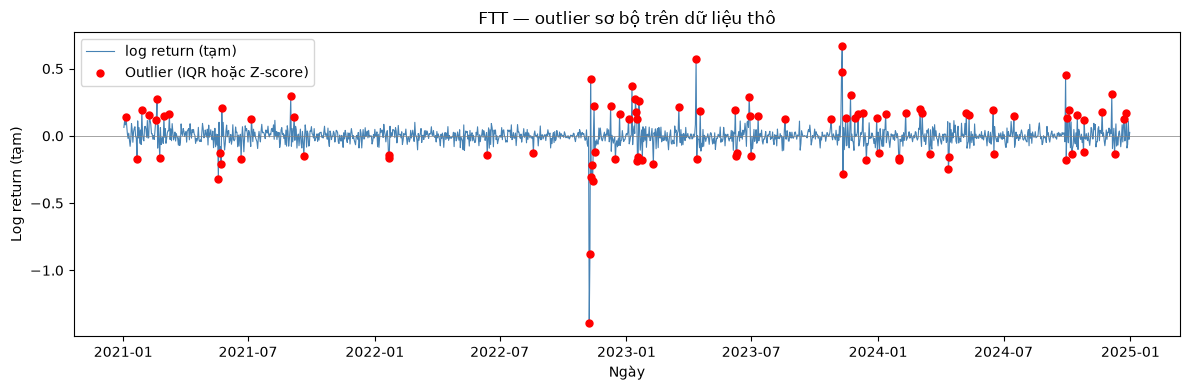

OUTLIER CHECK (SƠ BỘ) — S&P 500
Outlier theo IQR:      41
Outlier theo Z-score:  9
Outlier theo cả hai:   9


,trade_date,tmp_log_return,outlier_iqr,outlier_zscore
468,2022-11-10,0.053953,True,True
426,2022-09-13,-0.044199,True,True
346,2022-05-18,-0.041234,True,True
363,2022-06-13,-0.039540,True,True
333,2022-04-29,-0.036959,True,True
337,2022-05-05,-0.036301,True,True
415,2022-08-26,-0.034269,True,True
366,2022-06-16,-0.033052,True,True
339,2022-05-09,-0.032562,True,True
481,2022-11-30,0.030479,True,False


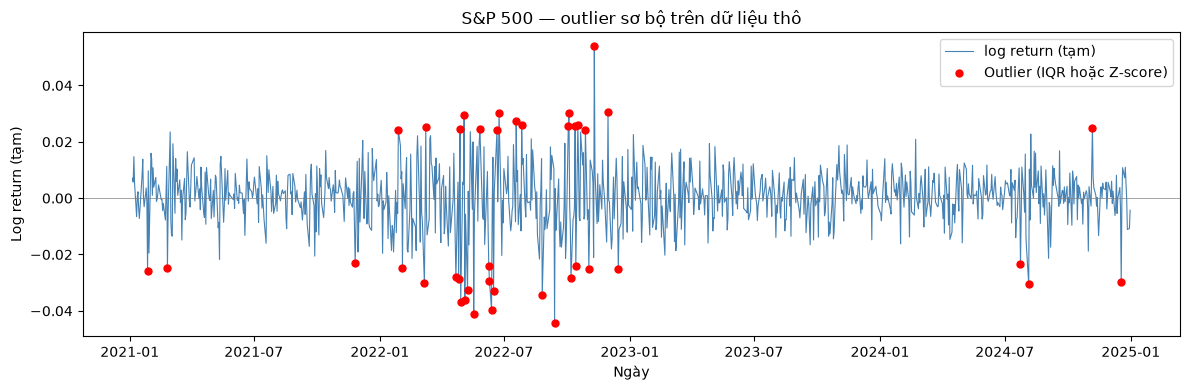

In [11]:
def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    valid = series.dropna()
    q1, q3 = valid.quantile(0.25), valid.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (series < lower) | (series > upper)

def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    valid = series.dropna()
    mean, std = valid.mean(), valid.std()
    if std == 0 or np.isnan(std):
        return pd.Series(False, index=series.index)
    z = (series - mean) / std
    return z.abs() > threshold

def outlier_check_raw(df, name):
    """Log return TẠM THỜI trên dữ liệu thô, chỉ để dò outlier sớm — không phải return chính thức."""
    tmp_log_return = np.log(df["close_price"] / df["close_price"].shift(1))
    outlier_iqr = detect_outliers_iqr(tmp_log_return)
    outlier_zscore = detect_outliers_zscore(tmp_log_return)
    outlier_mask = outlier_iqr | outlier_zscore

    print("="*60); print(f"OUTLIER CHECK (SƠ BỘ) — {name}"); print("="*60)
    print(f"Outlier theo IQR:      {int(outlier_iqr.sum())}")
    print(f"Outlier theo Z-score:  {int(outlier_zscore.sum())}")
    print(f"Outlier theo cả hai:   {int((outlier_iqr & outlier_zscore).sum())}")

    if outlier_mask.any():
        report = pd.DataFrame({
            "trade_date": df["trade_date"],
            "tmp_log_return": tmp_log_return,
            "outlier_iqr": outlier_iqr,
            "outlier_zscore": outlier_zscore,
        })
        display(
            report.loc[outlier_mask]
                  .assign(abs_return=lambda d: d["tmp_log_return"].abs())
                  .sort_values("abs_return", ascending=False)
                  .drop(columns="abs_return")
        )
    else:
        print("Không phát hiện outlier.")

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df["trade_date"], tmp_log_return, linewidth=0.8, color="steelblue", label="log return (tạm)")
    ax.scatter(df.loc[outlier_mask, "trade_date"], tmp_log_return[outlier_mask],
               color="red", s=25, zorder=5, label="Outlier (IQR hoặc Z-score)")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_title(f"{name} — outlier sơ bộ trên dữ liệu thô")
    ax.set_xlabel("Ngày"); ax.set_ylabel("Log return (tạm)")
    ax.legend(); fig.tight_layout(); plt.show()

    # Chỉ giữ trade_date + cờ để mang sang PHẦN 2 gắn lại — không phải dataset phân tích.
    return pd.DataFrame({
        "trade_date": df["trade_date"],
        "outlier_iqr": outlier_iqr,
        "outlier_zscore": outlier_zscore,
    })

ftt_outlier_flags_raw = outlier_check_raw(ftt_raw, "FTT")
sp500_outlier_flags_raw = outlier_check_raw(sp500_raw, "S&P 500")

## 1.9. TỔNG HỢP KẾT QUẢ QUALITY CHECK — Bước 10

**Ý nghĩa:** Tạo bảng kiểm tra nhanh trước khi bước sang preprocessing. Phát hiện duplicate/gap/outlier không có nghĩa là được phép tạo dữ liệu thay thế hay tự động xóa.

In [12]:
def quality_summary(df, name, ohlc_invalid, invalid_close, gap_report, outlier_flags):
    return {
        "asset": name, "rows": len(df),
        "min_date": df["trade_date"].min(), "max_date": df["trade_date"].max(),
        "duplicate_dates": int(df["trade_date"].duplicated().sum()),
        "missing_close": int(df["close_price"].isna().sum()),
        "invalid_close": int(invalid_close.sum()),
        "ohlc_invalid": int(ohlc_invalid.sum()),
        "gap_count": (int(len(gap_report)) if gap_report is not None else None),
        "outlier_iqr": int(outlier_flags["outlier_iqr"].sum()),
        "outlier_zscore": int(outlier_flags["outlier_zscore"].sum()),
        "sorted_ascending": df["trade_date"].is_monotonic_increasing,
    }

quality_report = pd.DataFrame([
    quality_summary(ftt_raw, "FTT", ftt_ohlc_invalid, ftt_invalid_close, ftt_gaps, ftt_outlier_flags_raw),
    quality_summary(sp500_raw, "S&P 500", sp500_ohlc_invalid, sp500_invalid_close, None, sp500_outlier_flags_raw),
])
display(quality_report)

,asset,rows,min_date,max_date,duplicate_dates,missing_close,invalid_close,ohlc_invalid,gap_count,outlier_iqr,outlier_zscore,sorted_ascending
0,FTT,1461,2021-01-01,2024-12-31,0,0,0,0,0.0,94,19,True
1,S&P 500,1005,2021-01-04,2024-12-31,0,0,0,0,NaN,41,9,True


# PHẦN 2 — TIỀN XỬ LÝ DỮ LIỆU

## Quy trình (Bước 11–18)

11. Sort theo `trade_date` (đã sort khi query ở bước 0.2, sort lại trong Pandas cho chắc).
12. Xóa duplicate theo `trade_date` **nếu thực sự tồn tại** (đã xác nhận ở bước 1.3), giữ bản ghi đầu.
13. Loại các dòng `close_price` không hợp lệ **nếu thực sự tồn tại** (đã xác nhận ở bước 1.7) — không fill/thay giá, chỉ loại dòng không dùng được để tính return.
14. **KHÔNG** fill giá.
15. **KHÔNG** interpolate giá.
16. **KHÔNG** xóa outlier chỉ vì nó "lớn" — outlier đã phát hiện ở bước 1.8 chỉ được gắn lại cờ (không tính lại) lên dữ liệu đã xử lý.
17. Tính return (simple & log) sau khi dữ liệu đã qua các bước kiểm tra/xử lý ở trên.
18. Kiểm tra lại dữ liệu cuối cùng.

Mục tiêu là **làm dữ liệu nhất quán chứ không làm chuỗi giá "đẹp" hơn dữ liệu quan sát được**.

## 2.1. CHUẨN HÓA, SORT, LOẠI DUPLICATE & GIÁ TRỊ INVALID — Bước 11–13

**Ý nghĩa:** Tạo dataframe làm việc trong memory (không phải dataset mới trên Supabase): chuẩn hóa `trade_date`, giới hạn đúng giai đoạn nghiên cứu, sort tăng dần (11), loại duplicate theo `trade_date` — giữ bản ghi đầu (12), và loại các dòng `close_price` không hợp lệ đã phát hiện ở bước 1.7 (13). Không fill/interpolate bất kỳ cột giá nào.

In [13]:
def preprocess_price_data(df, name):
    data = df.copy()
    data["trade_date"] = pd.to_datetime(data["trade_date"], errors="coerce")
    data = data[data["trade_date"].between(START_DATE, END_DATE - pd.Timedelta(days=1), inclusive="both")].copy()
    data = data.dropna(subset=["trade_date"])

    # Bước 11: sort tăng dần
    data = data.sort_values("trade_date", kind="stable")

    # Bước 12: loại duplicate theo trade_date — chỉ vì đã xác nhận tồn tại ở bước 1.3
    n_before = len(data)
    data = data.drop_duplicates(subset=["trade_date"], keep="first")
    n_dup_removed = n_before - len(data)

    # Bước 13: loại dòng close_price không hợp lệ — đã xác nhận tồn tại ở bước 1.7
    invalid_close = data["close_price"].isna() | ~np.isfinite(data["close_price"]) | (data["close_price"] <= 0)
    n_invalid_removed = int(invalid_close.sum())
    data = data.loc[~invalid_close].reset_index(drop=True)

    print(f"{name}: {len(data):,} dòng sau preprocessing")
    print(f"  - Duplicate đã loại (bước 12): {n_dup_removed}")
    print(f"  - Close không hợp lệ đã loại (bước 13): {n_invalid_removed}")
    print(f"Khoảng ngày: {data['trade_date'].min()} -> {data['trade_date'].max()}")
    return data

ftt_processed = preprocess_price_data(ftt_raw, "FTT")
sp500_processed = preprocess_price_data(sp500_raw, "S&P 500")
print("Không có bước fill/interpolate giá (bước 14-15).")

FTT: 1,461 dòng sau preprocessing
  - Duplicate đã loại (bước 12): 0
  - Close không hợp lệ đã loại (bước 13): 0
Khoảng ngày: 2021-01-01 00:00:00 -> 2024-12-31 00:00:00
S&P 500: 1,005 dòng sau preprocessing
  - Duplicate đã loại (bước 12): 0
  - Close không hợp lệ đã loại (bước 13): 0
Khoảng ngày: 2021-01-04 00:00:00 -> 2024-12-31 00:00:00
Không có bước fill/interpolate giá (bước 14-15).


## 2.2. KIỂM TRA LẠI SAU SORT / DEDUPLICATE — một phần Bước 18

**Ý nghĩa:** Đảm bảo dataframe cuối cùng được sort, không duplicate, không còn close không hợp lệ và vẫn nằm trong khoảng nghiên cứu.

In [14]:
def final_price_check(df, name):
    print("="*60); print(f"FINAL PRICE CHECK — {name}"); print("="*60)
    print("Rows:", len(df))
    print("Date sorted:", df["trade_date"].is_monotonic_increasing)
    print("Duplicate dates:", df["trade_date"].duplicated().sum())
    print("Min date:", df["trade_date"].min())
    print("Max date:", df["trade_date"].max())
    print("Close null:", df["close_price"].isna().sum())
    print("Close <= 0:", (df["close_price"] <= 0).sum())

final_price_check(ftt_processed, "FTT")
final_price_check(sp500_processed, "S&P 500")

FINAL PRICE CHECK — FTT
Rows: 1461
Date sorted: True
Duplicate dates: 0
Min date: 2021-01-01 00:00:00
Max date: 2024-12-31 00:00:00
Close null: 0
Close <= 0: 0
FINAL PRICE CHECK — S&P 500
Rows: 1005
Date sorted: True
Duplicate dates: 0
Min date: 2021-01-04 00:00:00
Max date: 2024-12-31 00:00:00
Close null: 0
Close <= 0: 0


## 2.3. TẠO SIMPLE RETURN VÀ LOG RETURN — KHÔNG FILL GIÁ — Bước 17

**Ý nghĩa:** Tính biến động từ giá đóng cửa thực tế, sau khi dữ liệu đã qua toàn bộ bước kiểm tra/xử lý ở trên.

- FTT: nếu có gap > 1 ngày, return tại quan sát ngay sau gap được để `NaN`.
- S&P 500: return giữa hai phiên giao dịch liên tiếp; cuối tuần/ngày lễ không bị coi là lỗi.

In [15]:
def add_returns(df, price_col, prefix, check_daily_continuity=False):
    data = df.copy()
    data[f"{prefix}_simple_return"] = data[price_col].pct_change()
    data[f"{prefix}_log_return"] = np.log(data[price_col] / data[price_col].shift(1))
    if check_daily_continuity:
        day_diff = data["trade_date"].diff().dt.days
        gap_mask = day_diff > 1
        data.loc[gap_mask, [f"{prefix}_simple_return", f"{prefix}_log_return"]] = np.nan
    return data

ftt_processed = add_returns(ftt_processed, "close_price", "FTT", True)
sp500_processed = add_returns(sp500_processed, "close_price", "SP500", False)

display(ftt_processed[["trade_date","close_price","FTT_simple_return","FTT_log_return"]].head(10))
display(sp500_processed[["trade_date","close_price","SP500_simple_return","SP500_log_return"]].head(10))

,trade_date,close_price,FTT_simple_return,FTT_log_return
0,2021-01-01,5.821003,NaN,NaN
1,2021-01-02,6.199924,0.065095,0.063064
2,2021-01-03,6.923968,0.116783,0.110452
3,2021-01-04,7.514079,0.085227,0.081789
4,2021-01-05,8.664688,0.153127,0.142477
5,2021-01-06,9.390797,0.083801,0.080474
6,2021-01-07,9.562131,0.018245,0.018080
7,2021-01-08,9.380988,-0.018944,-0.019126
8,2021-01-09,9.570511,0.020203,0.020001
9,2021-01-10,9.308809,-0.027345,-0.027725


,trade_date,close_price,SP500_simple_return,SP500_log_return
0,2021-01-04,3700.65,NaN,NaN
1,2021-01-05,3726.86,0.007083,0.007058
2,2021-01-06,3748.14,0.005710,0.005694
3,2021-01-07,3803.79,0.014847,0.014738
4,2021-01-08,3824.68,0.005492,0.005477
5,2021-01-11,3799.61,-0.006555,-0.006576
6,2021-01-12,3801.19,0.000416,0.000416
7,2021-01-13,3809.84,0.002276,0.002273
8,2021-01-14,3795.54,-0.003753,-0.003761
9,2021-01-15,3768.25,-0.007190,-0.007216


## 2.4. KIỂM TRA RETURN SAU KHI TÍNH — một phần Bước 18

**Ý nghĩa:** NaN đầu chuỗi là bình thường vì chưa có giá ngày trước. NaN sau FTT gap là chủ ý; không được thay thế bằng giá/return giả.

In [16]:
def return_quality_check(df, name, cols):
    print("="*60); print(f"RETURN QUALITY CHECK — {name}"); print("="*60)
    for col in cols:
        print(f"{col}: NaN={df[col].isna().sum()}, Inf={np.isinf(df[col].dropna()).sum()}")

return_quality_check(ftt_processed,"FTT",["FTT_simple_return","FTT_log_return"])
return_quality_check(sp500_processed,"S&P 500",["SP500_simple_return","SP500_log_return"])

RETURN QUALITY CHECK — FTT
FTT_simple_return: NaN=1, Inf=0
FTT_log_return: NaN=1, Inf=0
RETURN QUALITY CHECK — S&P 500
SP500_simple_return: NaN=1, Inf=0
SP500_log_return: NaN=1, Inf=0


## 2.5. GẮN LẠI CỜ OUTLIER TỪ PHẦN 1 — Bước 16 (không xóa)

**Ý nghĩa:** Outlier đã được phát hiện ở bước 1.8 trên dữ liệu thô. Ở đây **không tính lại, không xóa** — chỉ map lại đúng các cờ đó theo `trade_date` lên `ftt_processed` / `sp500_processed` để tiện tham khảo khi phân tích, đúng nguyên tắc bước 16: không xóa outlier chỉ vì nó lớn.

In [17]:
def attach_outlier_flags(df, flags_raw, prefix):
    """Map lại cờ outlier đã tính ở PHẦN 1 (bước 1.8) theo trade_date — không tính lại."""
    flags = flags_raw.drop_duplicates(subset="trade_date", keep="first").set_index("trade_date")
    df[f"{prefix}_outlier_iqr"] = df["trade_date"].map(flags["outlier_iqr"]).fillna(False).astype(bool)
    df[f"{prefix}_outlier_zscore"] = df["trade_date"].map(flags["outlier_zscore"]).fillna(False).astype(bool)
    return df

ftt_processed = attach_outlier_flags(ftt_processed, ftt_outlier_flags_raw, "FTT")
sp500_processed = attach_outlier_flags(sp500_processed, sp500_outlier_flags_raw, "SP500")

print("FTT — outlier giữ nguyên trong dữ liệu:",
      int(ftt_processed["FTT_outlier_iqr"].sum()), "(IQR),",
      int(ftt_processed["FTT_outlier_zscore"].sum()), "(Z-score)")
print("S&P 500 — outlier giữ nguyên trong dữ liệu:",
      int(sp500_processed["SP500_outlier_iqr"].sum()), "(IQR),",
      int(sp500_processed["SP500_outlier_zscore"].sum()), "(Z-score)")
print("Không có dòng nào bị xóa vì outlier (bước 16).")

FTT — outlier giữ nguyên trong dữ liệu: 94 (IQR), 19 (Z-score)
S&P 500 — outlier giữ nguyên trong dữ liệu: 41 (IQR), 9 (Z-score)
Không có dòng nào bị xóa vì outlier (bước 16).


## 2.6. KIỂM TRA GAP LẠI SAU PREPROCESSING — FTT (bổ sung, ngoài 18 bước chuẩn)

**Ý nghĩa:** Xác nhận preprocessing không tạo thêm ngày. Nếu gap tồn tại, gap vẫn tồn tại; chỉ return bị ảnh hưởng được để thiếu.

In [18]:
ftt_gaps_after = check_ftt_calendar_gaps(ftt_processed)
print("Số dòng FTT:", len(ftt_processed))
print("Số ngày unique:", ftt_processed["trade_date"].nunique())
print("Số duplicate:", ftt_processed["trade_date"].duplicated().sum())

FTT CALENDAR GAP CHECK
Số gap > 1 ngày: 0
Không phát hiện gap > 1 ngày.
Số dòng FTT: 1461
Số ngày unique: 1461
Số duplicate: 0


## 2.7. KIỂM TRA EVENT WINDOW (bổ sung, ngoài 18 bước chuẩn)

**Ý nghĩa:** Xác nhận dữ liệu FTT có quan sát quanh ngày sự kiện. FTT vẫn giữ lịch 24/7; không ép S&P 500 có dữ liệu vào ngày thị trường Mỹ nghỉ.

Ngày sự kiện bên dưới có thể thay bằng event date chính thức của nghiên cứu.

In [19]:
EVENT_DATE = pd.Timestamp("2022-11-08")

def check_event_window(df, name, event_date, window_days=3):
    start = event_date - pd.Timedelta(days=window_days)
    end = event_date + pd.Timedelta(days=window_days)
    window = df[df["trade_date"].between(start,end,inclusive="both")].copy()
    print(f"{name}: {start.date()} -> {end.date()} | {len(window)} quan sát")
    display(window[["trade_date","close_price"]])
    return window

ftt_event_window = check_event_window(ftt_processed,"FTT",EVENT_DATE)
sp500_event_window = check_event_window(sp500_processed,"S&P 500",EVENT_DATE)

FTT: 2022-11-05 -> 2022-11-11 | 7 quan sát


,trade_date,close_price
673,2022-11-05,24.059296
674,2022-11-06,22.269251
675,2022-11-07,22.142197
676,2022-11-08,5.518904
677,2022-11-09,2.300628
678,2022-11-10,3.516938
679,2022-11-11,2.590422


S&P 500: 2022-11-05 -> 2022-11-11 | 5 quan sát


,trade_date,close_price
465,2022-11-07,3806.80
466,2022-11-08,3828.11
467,2022-11-09,3748.57
468,2022-11-10,3956.37
469,2022-11-11,3992.93


## 2.8. DATAFRAME FTT CUỐI CÙNG PHỤC VỤ TRỰC QUAN HÓA (bổ sung, ngoài 18 bước chuẩn)

**Ý nghĩa:** `ftt_processed` giữ các quan sát giá FTT thực tế trong 2021–2024, đã chuẩn hóa, sort, có return và cờ outlier. Không tạo ngày giả và không fill/interpolate giá. Đây là dataframe chính cho biểu đồ giá, return, rolling volatility, ACF, ADF và event analysis — được thực hiện ở notebook phân tích/trực quan hóa phía sau, không phải ở đây.

In [20]:
print("FTT PROCESSED")
print("="*60)
print("Shape:", ftt_processed.shape)
print("Min date:", ftt_processed["trade_date"].min())
print("Max date:", ftt_processed["trade_date"].max())
print("Duplicate:", ftt_processed["trade_date"].duplicated().sum())
print("Sorted:", ftt_processed["trade_date"].is_monotonic_increasing)
display(ftt_processed[["trade_date","open_price","high_price","low_price","close_price","volume",
                        "FTT_simple_return","FTT_log_return","FTT_outlier_iqr","FTT_outlier_zscore"]].head(10))

FTT PROCESSED
Shape: (1461, 13)
Min date: 2021-01-01 00:00:00
Max date: 2024-12-31 00:00:00
Duplicate: 0
Sorted: True


,trade_date,open_price,high_price,low_price,close_price,volume,FTT_simple_return,FTT_log_return,FTT_outlier_iqr,FTT_outlier_zscore
0,2021-01-01,5.766584,5.903603,5.711738,5.821003,11885409,NaN,NaN,False,False
1,2021-01-02,5.819984,6.282498,5.739230,6.199924,23398220,0.065095,0.063064,False,False
2,2021-01-03,6.201133,7.007523,6.171834,6.923968,31046653,0.116783,0.110452,False,False
3,2021-01-04,6.948680,7.632146,6.358218,7.514079,40526109,0.085227,0.081789,False,False
4,2021-01-05,7.528216,8.714947,7.081120,8.664688,49479278,0.153127,0.142477,True,False
5,2021-01-06,8.671285,9.390797,8.425946,9.390797,31404628,0.083801,0.080474,False,False
6,2021-01-07,9.386493,10.004872,9.215244,9.562131,46303337,0.018245,0.018080,False,False
7,2021-01-08,9.569239,9.726429,8.452265,9.380988,42286268,-0.018944,-0.019126,False,False
8,2021-01-09,9.370450,9.636120,8.728044,9.570511,28498949,0.020203,0.020001,False,False
9,2021-01-10,9.571917,9.944797,8.657147,9.308809,31012393,-0.027345,-0.027725,False,False


# KẾT LUẬN PREPROCESSING

### Đối chiếu với flow đã thống nhất

| # | Bước | Vị trí trong notebook |
|---|---|---|
| 01 | Load dữ liệu từ Supabase | 0.2 |
| 02 | Kiểm tra schema/datatype | 1.1 |
| 03 | Kiểm tra khoảng thời gian | 1.2 |
| 04 | Kiểm tra duplicate | 1.3 |
| 05 | Kiểm tra missing/null | 1.4 |
| 06 | Kiểm tra missing trading days/gap | 1.5 |
| 07 | Kiểm tra OHLC consistency | 1.6 |
| 08 | Kiểm tra giá trị bất hợp lệ | 1.7 |
| 09 | Kiểm tra outlier | 1.8 |
| 10 | Quality report | 1.9 |
| 11 | Sort theo trade_date khi query | 0.2 + 2.1 |
| 12 | Xóa duplicate nếu thực sự tồn tại | 2.1 |
| 13 | Xử lý giá trị invalid nếu có | 2.1 |
| 14 | KHÔNG fill giá | nguyên tắc xuyên suốt |
| 15 | KHÔNG interpolate giá | nguyên tắc xuyên suốt |
| 16 | KHÔNG xóa outlier chỉ vì nó "lớn" | 2.5 (gắn lại cờ, không xóa) |
| 17 | Tính return sau khi dữ liệu đã kiểm tra | 2.3 |
| 18 | Kiểm tra lại dữ liệu cuối cùng | 2.2 + 2.4 |

Các mục 2.6–2.8 (gap sau xử lý, event window, tổng quan FTT) là phần bổ sung phục vụ nghiên cứu cụ thể, nằm ngoài 18 bước chuẩn nhưng không vi phạm nguyên tắc nào ở trên.

### Dữ liệu
- Nguồn: Supabase `daily_prices`.
- Không tạo bảng preprocessing mới trên Supabase.
- Không lưu CSV local.

### FTT
- Giữ toàn bộ ngày thực tế có dữ liệu, giữ cuối tuần.
- Không fill/interpolate giá.
- Gap được phát hiện và giữ nguyên; return sau gap được để `NaN`.
- Outlier trên log return được phát hiện ở PHẦN 1 và gắn cờ lại ở PHẦN 2 (`FTT_outlier_iqr`, `FTT_outlier_zscore`) — không xóa/fill.
- `ftt_processed` là dataframe chính cho trực quan hóa và phân tích FTT.

### S&P 500
- Giữ theo lịch giao dịch thực tế; cuối tuần/ngày lễ không bị xem là missing.
- Không fill/interpolate giá.
- Outlier trên log return được gắn cờ (`SP500_outlier_iqr`, `SP500_outlier_zscore`), không xóa/fill.

### Dataframe sử dụng tiếp
- `ftt_processed`: FTT đầy đủ, đã có return + cờ outlier.
- `sp500_processed`: S&P 500 đã chuẩn hóa, đã có return + cờ outlier.
- Việc join/merge hai dataframe theo ngày giao dịch chung (nếu cần so sánh với benchmark) do notebook phân tích/trực quan hóa phía sau tự thực hiện. Preprocessing không tạo sẵn dataframe ghép để tránh trường hợp mỗi người dùng một bản merge khác nhau gây nhầm lẫn.

**Nguyên tắc cốt lõi:** preprocessing không được tạo ra chuỗi giá FTT giả liên tục; mục tiêu là làm dữ liệu nhất quán và đúng thứ tự, đồng thời bảo toàn thông tin thiếu/gap/outlier.

In [21]:
print("="*70)
print("PREPROCESSING COMPLETE")
print("="*70)
print(f"FTT processed:        {ftt_processed.shape}")
print(f"S&P 500 processed:    {sp500_processed.shape}")
print("\nFTT:", ftt_processed["trade_date"].min(), "->", ftt_processed["trade_date"].max())
print("S&P 500:", sp500_processed["trade_date"].min(), "->", sp500_processed["trade_date"].max())
print("\nKhông tạo CSV hoặc bảng preprocessing mới trên Supabase.")
print("Không fill/interpolate giá. Outlier chỉ gắn cờ, không xóa.")

PREPROCESSING COMPLETE
FTT processed:        (1461, 13)
S&P 500 processed:    (1005, 13)

FTT: 2021-01-01 00:00:00 -> 2024-12-31 00:00:00
S&P 500: 2021-01-04 00:00:00 -> 2024-12-31 00:00:00

Không tạo CSV hoặc bảng preprocessing mới trên Supabase.
Không fill/interpolate giá. Outlier chỉ gắn cờ, không xóa.
